In [1]:
import os, glob
import baltic as bt
from baltic import bt_utils, curonia

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec

In [2]:
base_path = 'C:/Users/iblag/Desktop/flud_res_2026/segment_MCC'

trees = {}
for tfile in glob.glob(os.path.join(base_path, '*.MCC.tree')):
    print(tfile)
    segNum = int(os.path.basename(tfile).split('.')[0].replace('segment', ''))

    trees[segNum] = bt.io.load_nexus(tfile, 'time')
    trees[segNum].treeStats()
    trees[segNum].sort_branches()


treeOrder = [trees[seg] for seg in sorted(trees.keys())]

C:/Users/iblag/Desktop/flud_res_2026/segment_MCC\segment1.MCC.tree

Tree height: 25.630102
Tree length: 393.468375
strictly bifurcating tree
annotations present

Numbers of objects in tree: 493 (246 nodes and 247 leaves)

C:/Users/iblag/Desktop/flud_res_2026/segment_MCC\segment2.MCC.tree

Tree height: 25.577174
Tree length: 414.485549
strictly bifurcating tree
annotations present

Numbers of objects in tree: 473 (236 nodes and 237 leaves)

C:/Users/iblag/Desktop/flud_res_2026/segment_MCC\segment3.MCC.tree

Tree height: 22.144979
Tree length: 362.120650
strictly bifurcating tree
annotations present

Numbers of objects in tree: 517 (258 nodes and 259 leaves)

C:/Users/iblag/Desktop/flud_res_2026/segment_MCC\segment4.MCC.tree

Tree height: 24.861526
Tree length: 506.168055
strictly bifurcating tree
annotations present

Numbers of objects in tree: 555 (277 nodes and 278 leaves)

C:/Users/iblag/Desktop/flud_res_2026/segment_MCC\segment5.MCC.tree

Tree height: 22.813897
Tree length: 346.5003

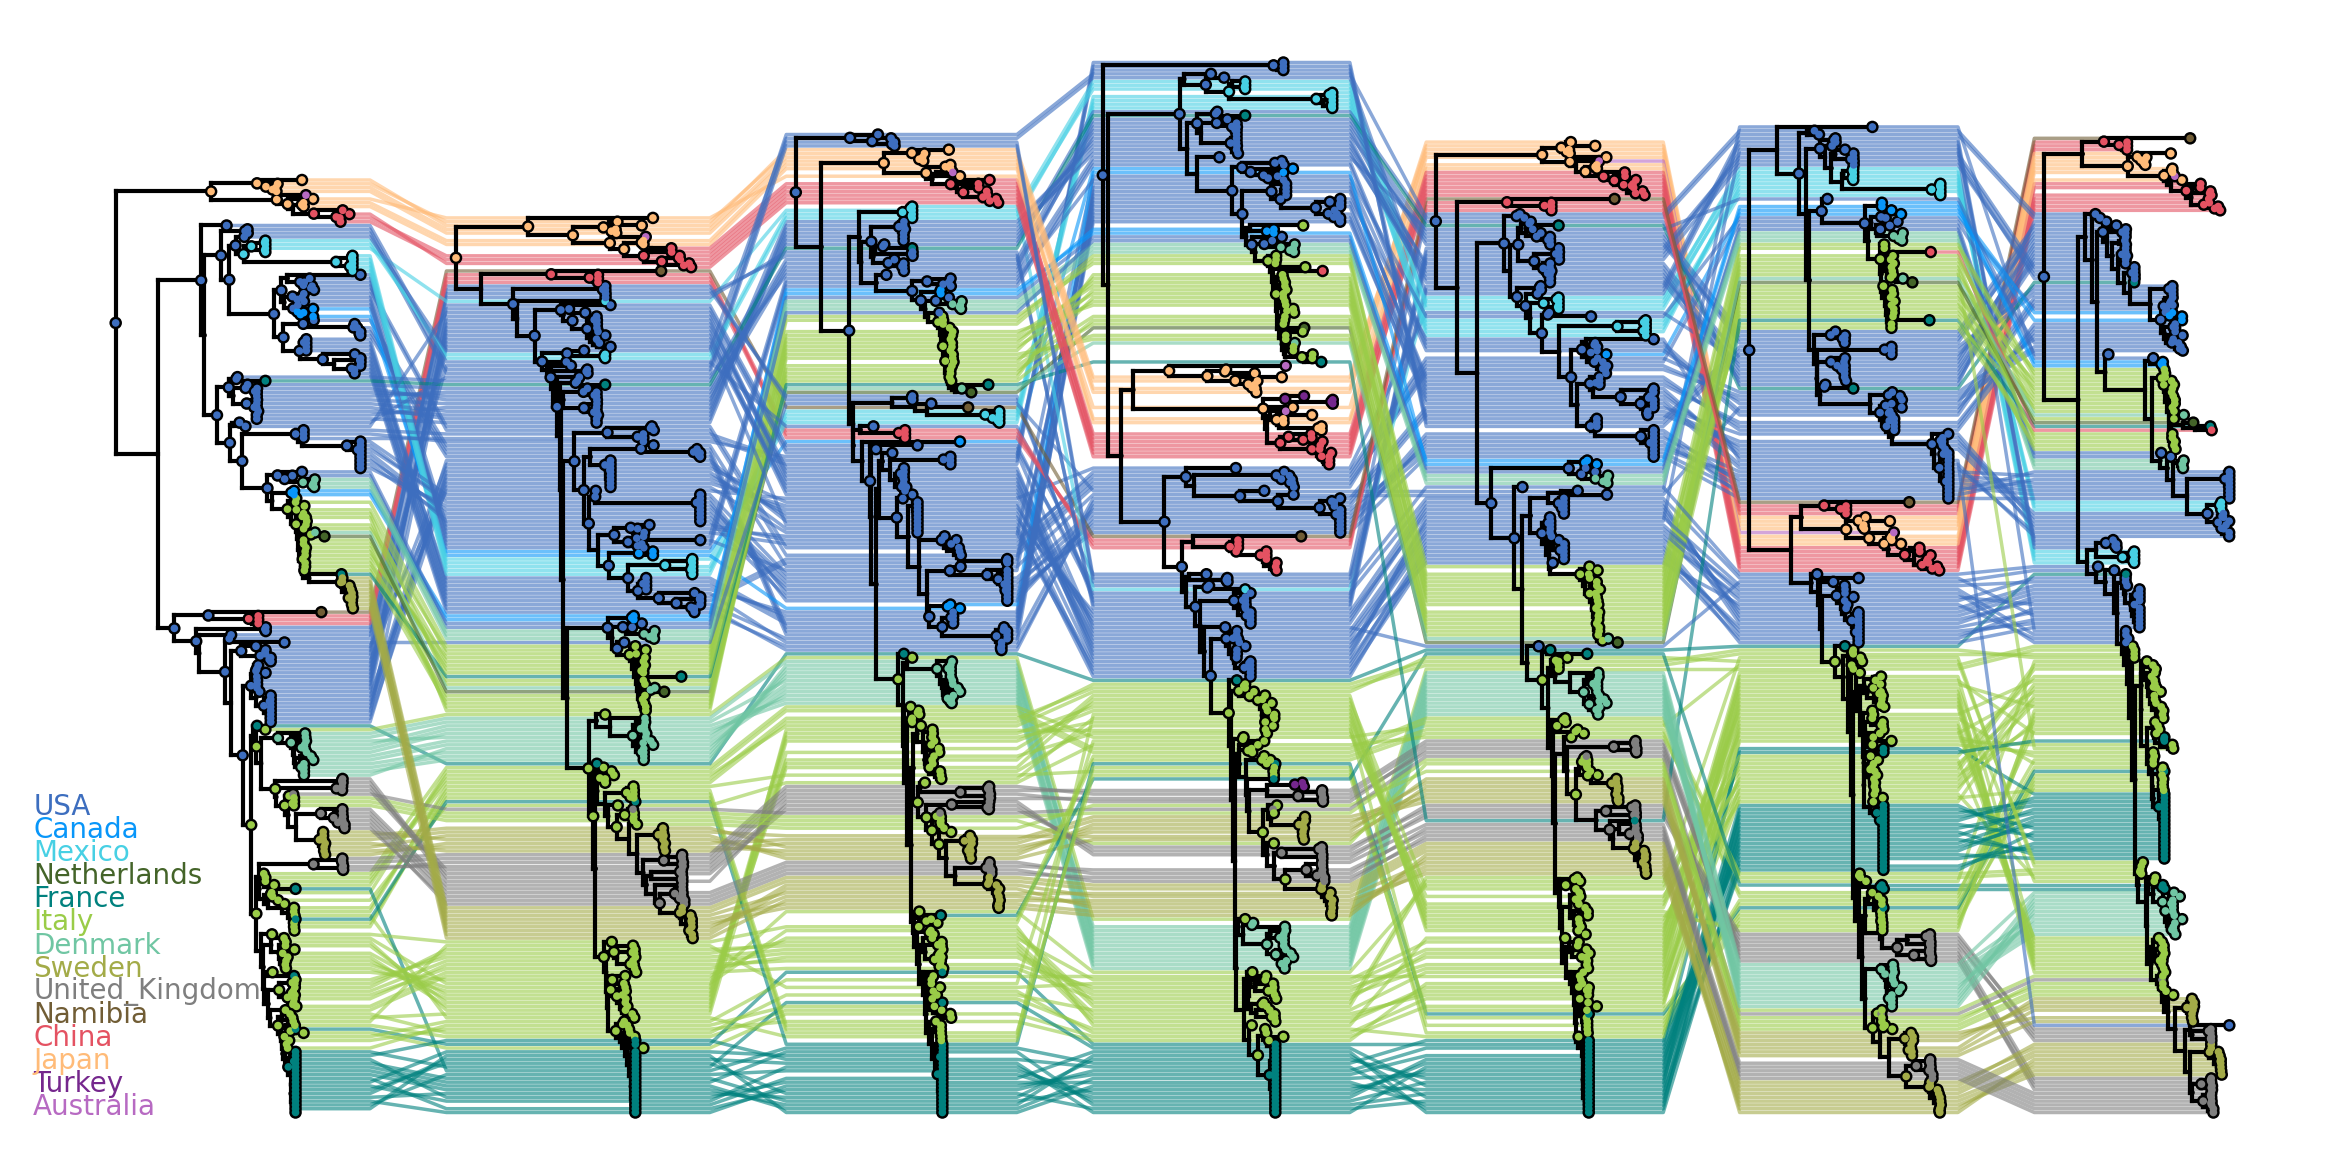

In [3]:
fig = plt.figure(figsize=(30, 15), facecolor='w')
gs = GridSpec(1, 1)

ax = plt.subplot(gs[0])

countryColours = {
    'USA': '#3D6EBF',
    'Canada': '#0896f9',
    'Mexico': "#47d0e4",
    
    'Netherlands': '#446429',
    'France': '#00817E',
    'Italy': '#9acc48',
    'Denmark': '#70c6a3',
    'Sweden': '#a3ab48',
    'United_Kingdom': '#7f7f7f',

    
    'Namibia': '#715d35',
    
    'China': '#E45262',
    'Japan': '#ffbb78',
    'Turkey': '#75278D',
    
    'Australia': '#B76AC2'
}

countryColours_reversed = dict(reversed(countryColours.items()))

colourDict = {}
for t in treeOrder:
    for k in t.get_external():
        colourDict[k.name] = countryColours[k.name.split('|')[1]]

treeOrder = curonia.plot_tangled_chain(ax=ax, treeList=treeOrder, lw=2.5, treeSpace=10, colourDict=colourDict, 
                                       normaliseY=False, treeKwargs={'width': 3}, alpha = 0.6)

c_func = lambda k: countryColours.get(k.traits.get('state'), 'black')

node_target = lambda k: 30 if (
    k.is_leaf() or (k.traits.get('posterior') > 0.95)
    ) else 0


for t in treeOrder:
        t.plot_points(
        ax,
        targetFxn=lambda k: True,
        xCoordinateFxn=lambda k: k.x,
        pointSizeFxn=node_target ,
        recomputeCoordinates=False,
        colourFxn= c_func
    )


for i, country in enumerate(countryColours_reversed):
    ax.text(0.01, 0.05 + i * 0.02, country, size=20, color=countryColours[country], ha='left', va='center', fontweight=400, transform=ax.transAxes)

bt_utils.clean_axes(ax)

plt.show()
